In [2]:
# %matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from scipy.fftpack import rfft, rfftfreq
from typing import List

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Noto Serif CJK SC'] + plt.rcParams['font.serif']
plt.rcParams['lines.linewidth'] = 1

In [3]:
data_list = {}

csv_list = ['3.5.2']
for i in csv_list:
    data_list[i] = pd.read_csv(i + '.csv')

def split_array(arr):
    arrs = np.vsplit(arr.T, arr.shape[1]) # a list of 2-d arrays in shape of (1, N)
    return [_.flatten() for _ in arrs] # flatten all sub-arrays

def split_csv(data): # only for compatibility
    return split_array(data.values)

In [4]:
# Graph manipulation

def plot_wrapper(plot_func):
    def inner(*args, **params):
        params = defaultdict(lambda: None, params)
        fig = plt.figure(num=params['num'], figsize=params['figsize'], clear=True, layout='constrained')
        ax = fig.add_subplot()
        plot_func(fig, ax, *args, **params)
        fig.suptitle(params['title'])
        plt.grid(True)
        plt.savefig(params['num'] + '.png')
        plt.show()
    return inner

@plot_wrapper
def plot_filter(fig, ax, freqs, amps, **params):
    ax.plot(freqs, amps)
    #ax.scatter(freqs, amps)
    ax.set_xlabel(r'Frequency (Hz)')
    ax.set_ylabel(r'Amplitude (V)')

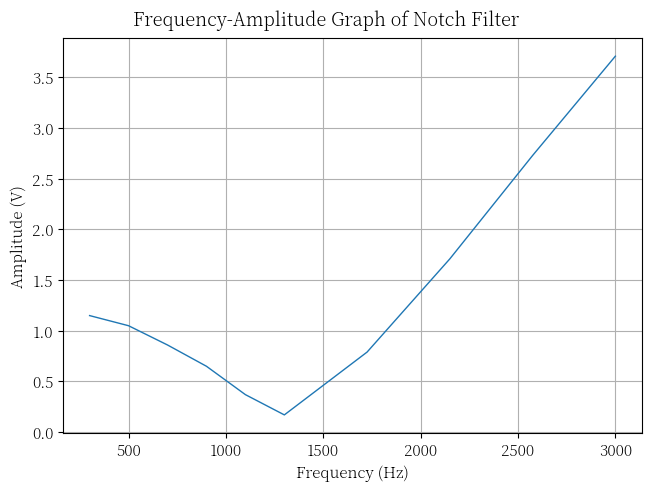

In [5]:
# 3.5.2

LABEL = '3.5.2'
plot_filter(*split_csv(data_list[LABEL]), title='Frequency-Amplitude Graph of Notch Filter', num=LABEL)